# **NOTEBOOK:** EDA_y_preparación.ipynb

**OBJETIVO:** Cargar, explorar y limpiar ENAHO 2025

## CONFIGURACIÓN INICIAL

### PASO 1 : IMPORTAR LIBRERIAS 

In [2]:
import gdown as gd
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

print("\nSe han importando las librerias correctamente. (Recuerda estar en el entorno virtual ven(3.11.0))")



Se han importando las librerias correctamente. (Recuerda estar en el entorno virtual ven(3.11.0))


### PASO 2: CONFIGURAR VISUALIZACIONES

In [3]:
# Configurar pandas para ver mejor los datos
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

print("\nOpciones de visualización configuradas")


Opciones de visualización configuradas


## CARGA DE DATOS

### PASO 1: DESCARGAR DATOS DESDE GOOGLE DRIVE

In [ ]:
import os

FILE_ID = "16IzaVtYm6K8IJNsPjk1Aev8z0i7uIlEF"
folder_url = f"https://drive.google.com/drive/folders/{FILE_ID}"

# Verificar si la carpeta ya existe
if os.path.exists("enaho2025"):
    print("Los archivos ya están descargados. Omitiendo descarga.")
    print("   (Si necesitas descargar de nuevo, elimina la carpeta enaho2025 manualmente)")
else:
    print("Descargando archivos desde Google Drive...")
    gd.download_folder(url=folder_url, quiet=False, use_cookies=False)
    print("Archivos descargados satisfactoriamente!")

Los archivos ya están descargados. Omitiendo descarga...
   (Si necesitas descargar de nuevo, elimina la carpeta 'enaho2025' manualmente)


### PASO 2: CARGAR 8 MODULOS DE ENAHO2025

In [5]:
import os
import pandas as pd

carpeta_datos = "enaho2025"

modulos_info = {
    'mod_01': 'modulo_01_vivienda.csv',
    'mod_02': 'modulo_02_miembros.csv',
    'mod_03': 'modulo_03_educacion.csv',
    'mod_05': 'modulo_05_empleo.csv',
    'mod_11': 'modulo_11_servicios.csv',
    'mod_16': 'modulo_16_equipamiento.csv',
    'mod_34': 'modulo_34_sumarias.csv',
    'mod_37': 'modulo_37_programas.csv'
}

print("Cargando modulos...")
print("")

modulos = {}

for nombre_corto, nombre_archivo in modulos_info.items():
    ruta_archivo = os.path.join(carpeta_datos, nombre_archivo)
    
    if not os.path.exists(ruta_archivo):
        print(f"{nombre_corto}: NO ENCONTRADO - {ruta_archivo}")
        continue
    
    # Probar diferentes delimitadores
    delimitadores = [',', ';', '|', '\t']
    cargo_exitoso = False
    
    for delim in delimitadores:
        try:
            # Leer todo el archivo con este delimitador
            df_temp = pd.read_csv(
                ruta_archivo, 
                encoding='latin-1', 
                delimiter=delim,
                on_bad_lines='skip'
            )
            
            # Si tiene mas de 1 columna y las filas son razonables, es el correcto
            if df_temp.shape[1] > 1 and df_temp.shape[0] > 100:
                modulos[nombre_corto] = df_temp
                n_filas = len(modulos[nombre_corto])
                n_cols = modulos[nombre_corto].shape[1]
                print(f"{nombre_corto}: {n_filas:>8,} filas x {n_cols:>3} columnas [delim: '{delim}']")
                cargo_exitoso = True
                break
        except:
            continue
    
    if not cargo_exitoso:
        # Intentar con deteccion automatica
        try:
            df_temp = pd.read_csv(
                ruta_archivo, 
                encoding='latin-1', 
                sep=None, 
                engine='python',
                on_bad_lines='skip'
            )
            if df_temp.shape[1] > 1:
                modulos[nombre_corto] = df_temp
                n_filas = len(modulos[nombre_corto])
                n_cols = modulos[nombre_corto].shape[1]
                print(f"{nombre_corto}: {n_filas:>8,} filas x {n_cols:>3} columnas [delim: auto]")
                cargo_exitoso = True
        except:
            pass
    
    if not cargo_exitoso:
        print(f"{nombre_corto}: ERROR - No se pudo leer correctamente")

print("")
print(f"Total modulos cargados: {len(modulos)}/{len(modulos_info)}")

Cargando modulos...

mod_01:   44,599 filas x 336 columnas [delim: ';']
mod_02:  115,145 filas x  40 columnas [delim: ';']
mod_03:  104,446 filas x 495 columnas [delim: ';']
mod_05:   84,853 filas x 1413 columnas [delim: ';']
mod_11:  269,616 filas x  38 columnas [delim: ';']
mod_16:  202,212 filas x  47 columnas [delim: ';']
mod_34:   33,702 filas x 161 columnas [delim: ';']
mod_37:   33,702 filas x  44 columnas [delim: ';']

Total modulos cargados: 8/8


## ANÁLISIS EXPLORATORIO DE DATOS PRINCIPAL (ANTES DE LIMPIAR)

### PASO 1: ESTRUCTURA DE CADA MODULO (FILAS, COLUMNAS, MEMORIA)

¿Cuántos datos? ¿Qué columnas? ¿Qué tipos?

In [26]:
print("ESTRUCTURA DE CADA MODULO")

for nombre, df in modulos.items():
    print(f"\nModulo > {nombre.upper()}")
    print(f"Filas: {df.shape[0]:,}")
    print(f"Columnas: {df.shape[1]}")
    print(f"Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    
    # Mostrar tipos de datos resumidos
    tipos = df.dtypes.value_counts()
    tipos_str = ", ".join([f"{tipo}: {count}" for tipo, count in tipos.items()])
    print(f"Tipos: {tipos_str}")
    
    # Mostrar primeras 5 columnas (sin importar cuántas haya)
    print(f"Primeras 5 columnas: {df.columns[:5].tolist()}")
    
    # Mostrar últimas 5 columnas
    if df.shape[1] > 5:
        print(f"Ultimas 5 columnas: {df.columns[-5:].tolist()}")

print("\nEstructura revisada")

ESTRUCTURA DE CADA MODULO

Modulo > MOD_01
Filas: 44,599
Columnas: 336
Memoria: 765.3 MB
Tipos: str: 304, int64: 32
Primeras 5 columnas: ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR']
Ultimas 5 columnas: ['NCONGLOME', 'SUB_CONGLOME', 'LONGITUD', 'LATITUD', 'ALTITUD']

Modulo > MOD_02
Filas: 115,145
Columnas: 40
Memoria: 179.7 MB
Tipos: str: 26, int64: 14
Primeras 5 columnas: ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR']
Ultimas 5 columnas: ['T211', 'TICUEST01', 'FACPOB07', 'NCONGLOME', 'SUB_CONGLOME']

Modulo > MOD_03
Filas: 104,446
Columnas: 495
Memoria: 2758.3 MB
Tipos: str: 471, int64: 21, object: 3
Primeras 5 columnas: ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR']
Ultimas 5 columnas: ['I315B', 'FACTOR07', 'FACTORA07', 'NCONGLOME', 'SUB_CONGLOME']

Modulo > MOD_05
Filas: 84,853
Columnas: 1413
Memoria: 6087.2 MB
Tipos: str: 1238, int64: 125, object: 50
Primeras 5 columnas: ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR']
Ultimas 5 columnas: ['I541A', 'OCU500', 'FAC500A', 'NCONGLO

### PASO 2: VISTA PREVIA DE DATOS (PRIMERAS FILAS, MUESTRAS)

¿Qué valores tienen las primeras filas?

In [6]:
print("VISTA PREVIA DE LOS DATOS")

for nombre, df in modulos.items():
    print(f"\n{nombre.upper()} - Primeras 3 filas:")
    # Mostrar solo primeras 6 columnas para no saturar
    print(df.iloc[:, :6].head(3))
    
    print(f"\n{nombre.upper()} - Muestra aleatoria (3 filas):")
    print(df.iloc[:, :6].sample(3))
    
    print("-" * 50)

VISTA PREVIA DE LOS DATOS

MOD_01 - Primeras 3 filas:
    AÑO  MES  CONGLOME  VIVIENDA  HOGAR  UBIGEO
0  2025    1     15009        12     11   10101
1  2025    1     15009        25     11   10101
2  2025    1     15009        36     11   10101

MOD_01 - Muestra aleatoria (3 filas):
        AÑO  MES  CONGLOME  VIVIENDA  HOGAR  UBIGEO
25960  2025    8     15137        95     11   10706
7150   2025    2     20105        90     11  240301
43797  2025   12     19540        14     11  210111
--------------------------------------------------

MOD_02 - Primeras 3 filas:
    AÑO  MES  CONGLOME  VIVIENDA  HOGAR  CODPERSO
0  2025    1     15009        12     11         1
1  2025    1     15009        12     11         2
2  2025    1     15009        25     11         1

MOD_02 - Muestra aleatoria (3 filas):
         AÑO  MES  CONGLOME  VIVIENDA  HOGAR  CODPERSO
114630  2025   12     20606       113     11         3
111561  2025   12     18624        93     11         1
96826   2025   11     15

### PASO 3: ANALISIS DE VALORES NULOS 

¿Hay celdas vacías? ¿Cuántas? ¿En qué columnas?

In [7]:
print("\n" + "="*80)
print("ANALISIS DE VALORES NULOS")
print("="*80)

resumen_nulos = []

for nombre, df in modulos.items():
    total_celdas = df.shape[0] * df.shape[1]
    total_nulos = df.isnull().sum().sum()
    pct_nulos = (total_nulos / total_celdas) * 100
    
    nulos_por_col = df.isnull().sum()
    cols_con_nulos = nulos_por_col[nulos_por_col > 0]
    
    resumen_nulos.append({
        'Modulo': nombre.upper(),
        'Total Celdas': total_celdas,
        'Total Nulos': total_nulos,
        '% Nulos': f"{pct_nulos:.2f}%",
        'Cols con Nulos': len(cols_con_nulos)
    })
    
    print(f"\nModulo > {nombre.upper()}")
    print(f"Total celdas: {total_celdas:,}")
    print(f"Total nulos: {total_nulos:,} ({pct_nulos:.2f}%)")
    print(f"Columnas con nulos: {len(cols_con_nulos)} de {df.shape[1]}")
    
    if len(cols_con_nulos) > 0:
        print(f"Top 3 columnas con mas nulos:")
        for col, nulos in nulos_por_col.nlargest(3).items():
            pct = (nulos / len(df)) * 100
            print(f"      - {col}: {nulos:,} ({pct:.1f}%)")

print("\n" + "-"*60)
print("RESUMEN DE VALORES NULOS:")
print("-"*60)
print(pd.DataFrame(resumen_nulos).to_string(index=False))


ANALISIS DE VALORES NULOS

Modulo > MOD_01
Total celdas: 14,985,264
Total nulos: 0 (0.00%)
Columnas con nulos: 0 de 336

Modulo > MOD_02
Total celdas: 4,605,800
Total nulos: 0 (0.00%)
Columnas con nulos: 0 de 40

Modulo > MOD_03
Total celdas: 51,700,770
Total nulos: 0 (0.00%)
Columnas con nulos: 0 de 495

Modulo > MOD_05
Total celdas: 119,897,289
Total nulos: 0 (0.00%)
Columnas con nulos: 0 de 1413

Modulo > MOD_11
Total celdas: 10,245,408
Total nulos: 0 (0.00%)
Columnas con nulos: 0 de 38

Modulo > MOD_16
Total celdas: 9,503,964
Total nulos: 0 (0.00%)
Columnas con nulos: 0 de 47

Modulo > MOD_34
Total celdas: 5,426,022
Total nulos: 0 (0.00%)
Columnas con nulos: 0 de 161

Modulo > MOD_37
Total celdas: 1,482,888
Total nulos: 0 (0.00%)
Columnas con nulos: 0 de 44

------------------------------------------------------------
RESUMEN DE VALORES NULOS:
------------------------------------------------------------
Modulo  Total Celdas  Total Nulos % Nulos  Cols con Nulos
MOD_01      14985264

### PASO 4: DETECCION DE VALORES ESPECIALES

¿Hay nulos que fueron codificados? 

In [8]:
print("\n" + "="*80)
print("BUSCANDO VALORES QUE PARECEN NULOS CODIFICADOS")
print("="*80)

valores_sospechosos = [99, 999, 9999, -1, -9, 888, 99999]

for nombre, df in modulos.items():
    print(f"\nModulo >{nombre.upper()}")
    
    for col in df.columns[:10]:
        for valor in valores_sospechosos:
            if valor in df[col].values:
                count = df[col].eq(valor).sum()
                print(f"   Columna {col}: tiene el valor {valor} ({count} veces)")
                break


BUSCANDO VALORES QUE PARECEN NULOS CODIFICADOS

Modulo >MOD_01
   Columna VIVIENDA: tiene el valor 99 (259 veces)

Modulo >MOD_02
   Columna VIVIENDA: tiene el valor 99 (653 veces)

Modulo >MOD_03
   Columna VIVIENDA: tiene el valor 99 (598 veces)

Modulo >MOD_05
   Columna VIVIENDA: tiene el valor 99 (491 veces)

Modulo >MOD_11
   Columna VIVIENDA: tiene el valor 99 (1576 veces)

Modulo >MOD_16
   Columna VIVIENDA: tiene el valor 99 (1182 veces)

Modulo >MOD_34
   Columna VIVIENDA: tiene el valor 99 (197 veces)

Modulo >MOD_37
   Columna VIVIENDA: tiene el valor 99 (197 veces)


### PASO 5: ESTADISTICAS DESCRIPTIVAS 

¿Cuál es el promedio? ¿El mínimo? ¿El máximo?

In [ ]:
print("\n" + "="*70)
print("ESTADISTICAS DESCRIPTIVAS")
print("="*70)

for nombre, df in modulos.items():
    df_num = df.select_dtypes(include=['float64', 'int64'])
    
    if len(df_num.columns) > 0:
        print(f"\nModulo > {nombre.upper()} - Variables numericas ({len(df_num.columns)} columnas):")
        print(df_num.describe().round(2))
    else:
        print(f"\nModulo >{nombre.upper()} - No tiene variables numericas")


ESTADISTICAS DESCRIPTIVAS

Modulo: MOD_01 - Variables numericas (32 columnas):
           AÑO       MES  CONGLOME  VIVIENDA     HOGAR     UBIGEO   DOMINIO   ESTRATO   PERIODO    TIPENC       FECENT    RESULT  P1175$01  P1175$02  P1175$04  P1175$05  P1175$06  P1175$07  P1175$08  P1175$09  P1175$10  P1175$11  P1175$12  P1175$13  P1175$14  P1175$15  P1175$16  P1175$17  TICUEST01   CODCCPP  NCONGLOME  SUB_CONGLOME
count  44599.0  44599.00  44599.00  44599.00  44599.00   44599.00  44599.00  44599.00  44599.00  44599.00     44599.00  44599.00  44599.00  44599.00  44599.00  44599.00  44599.00  44599.00  44599.00  44599.00  44599.00  44599.00  44599.00  44599.00  44599.00   44599.0  44599.00  44599.00    44599.0  44599.00   44599.00      44599.00
mean    2025.0      6.51  17805.21     77.24     11.12  130583.15      4.92      4.15      2.50      2.47  20250665.51      2.31      0.51      0.03      0.01      0.00      0.00      0.00      0.18      0.00      0.00      0.05      0.02      0.06  

### PASO 6: HISTOGRAMAS (DISTRIBUCIONES)

¿Los datos son simétricos? ¿Hay sesgo?


HISTOGRAMAS - DISTRIBUCIONES

Modulo: MOD_01 - Generando histogramas


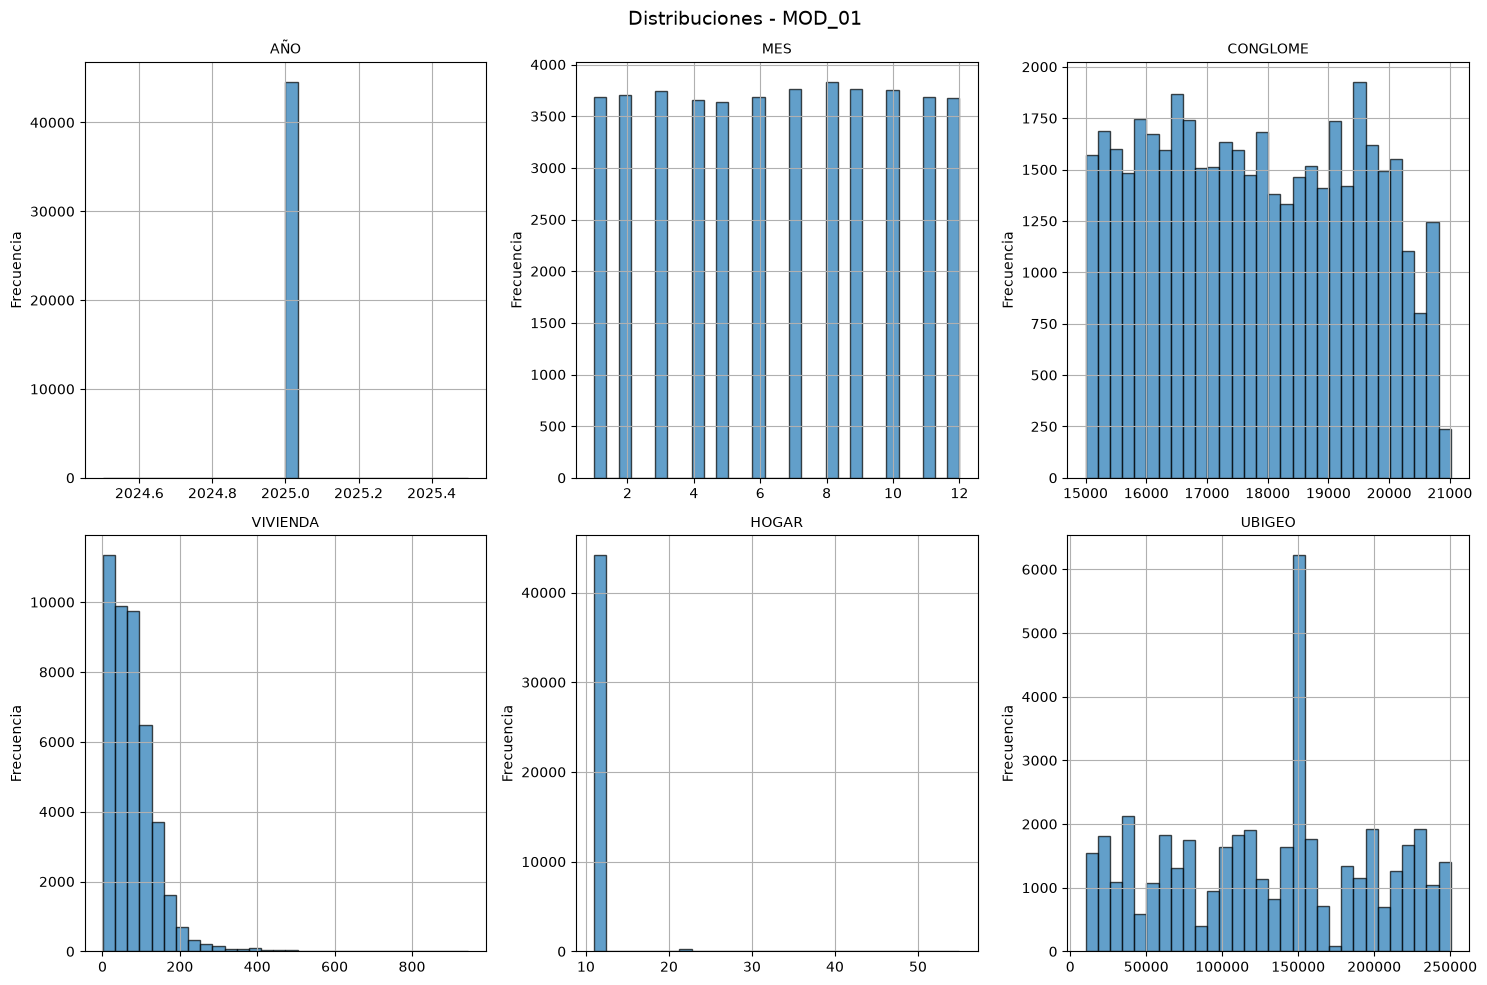


Modulo: MOD_02 - Generando histogramas


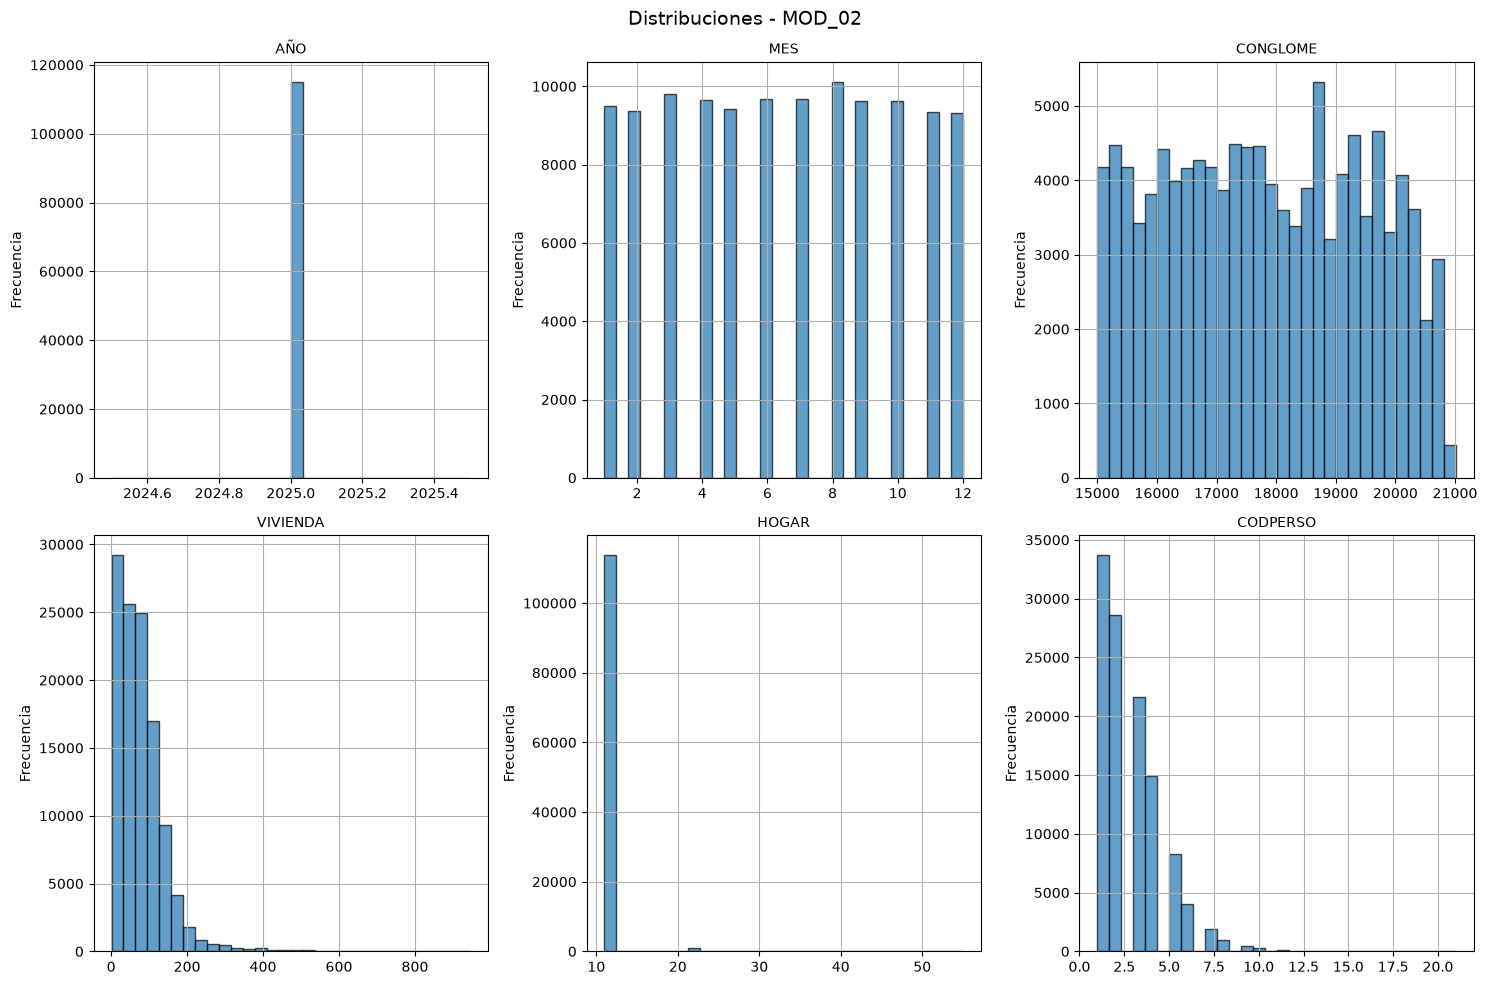


Modulo: MOD_03 - Generando histogramas


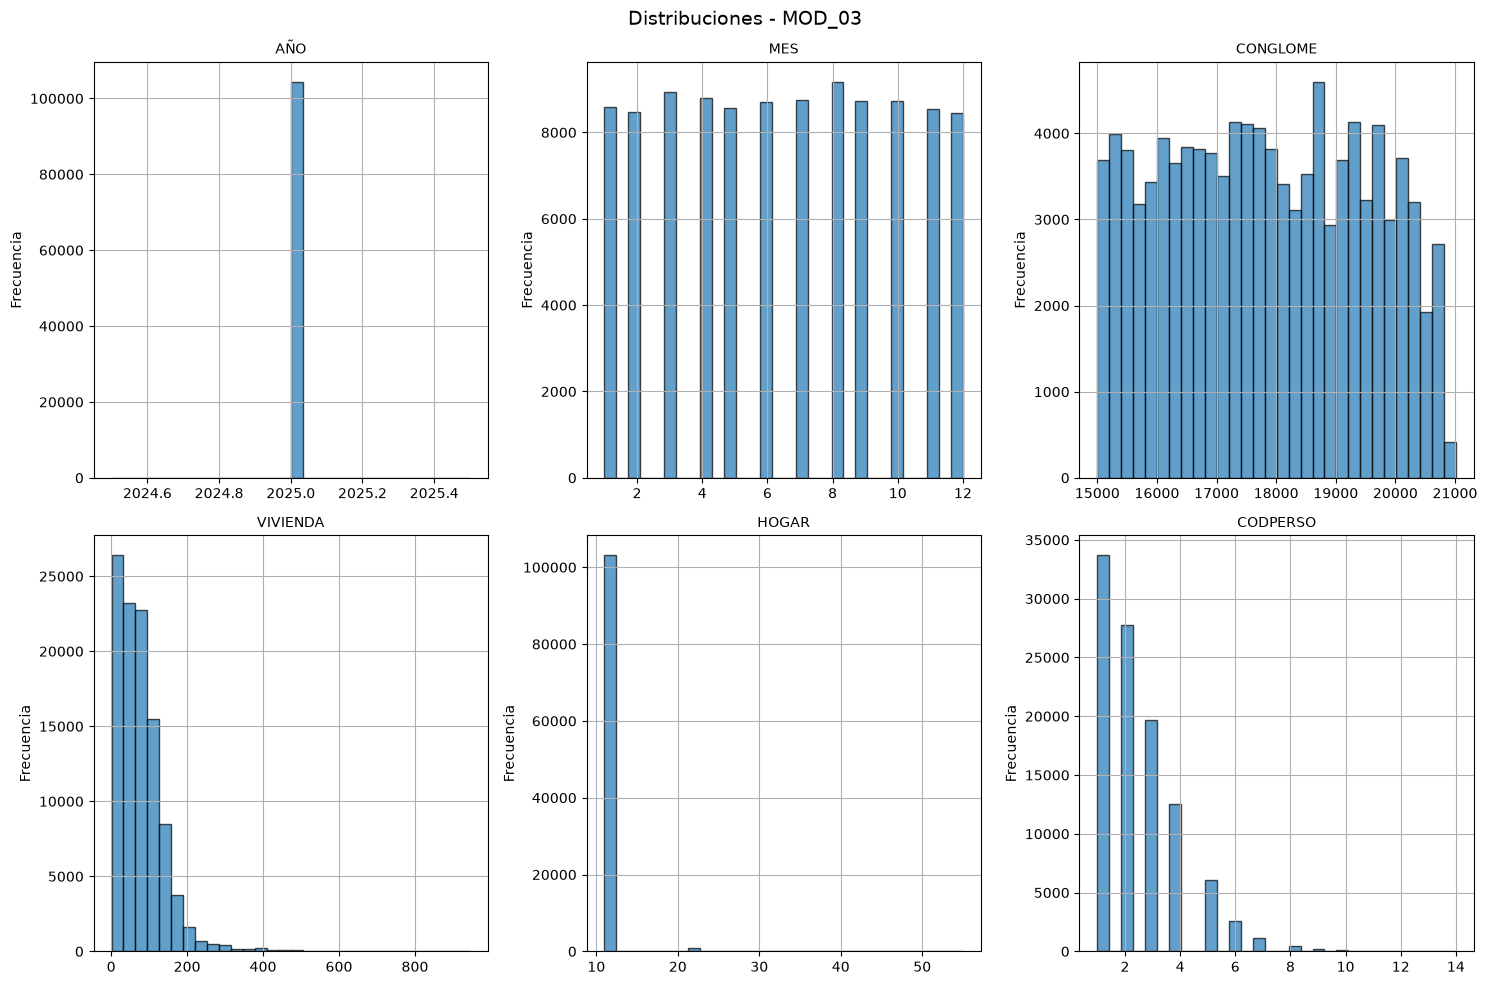


Modulo: MOD_05 - Generando histogramas


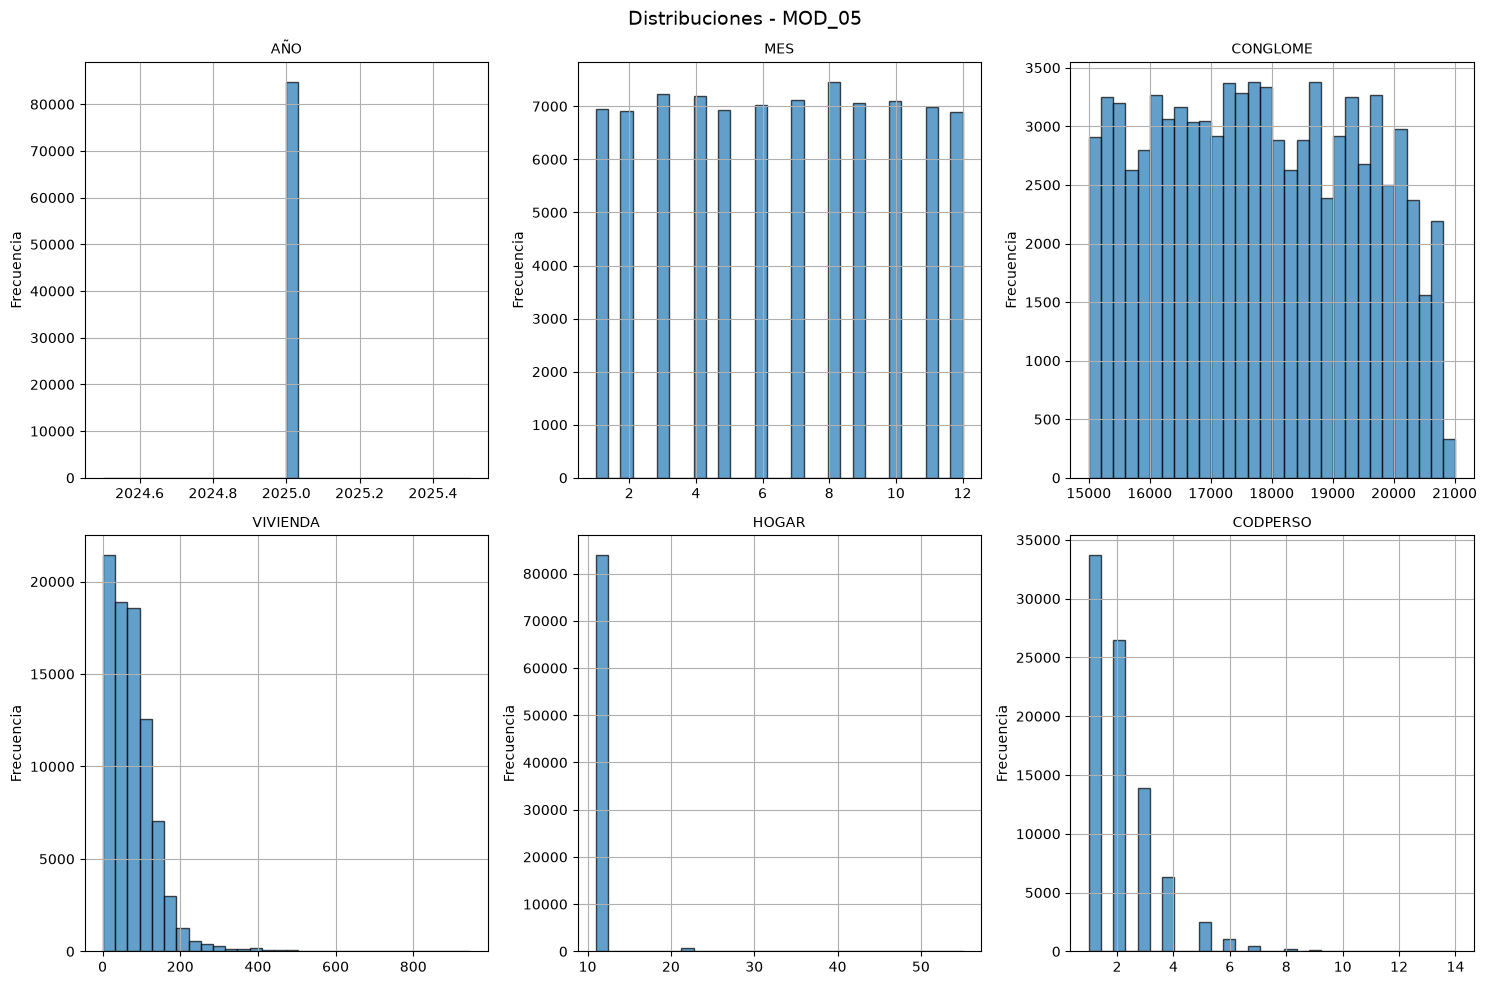


Modulo: MOD_11 - Generando histogramas


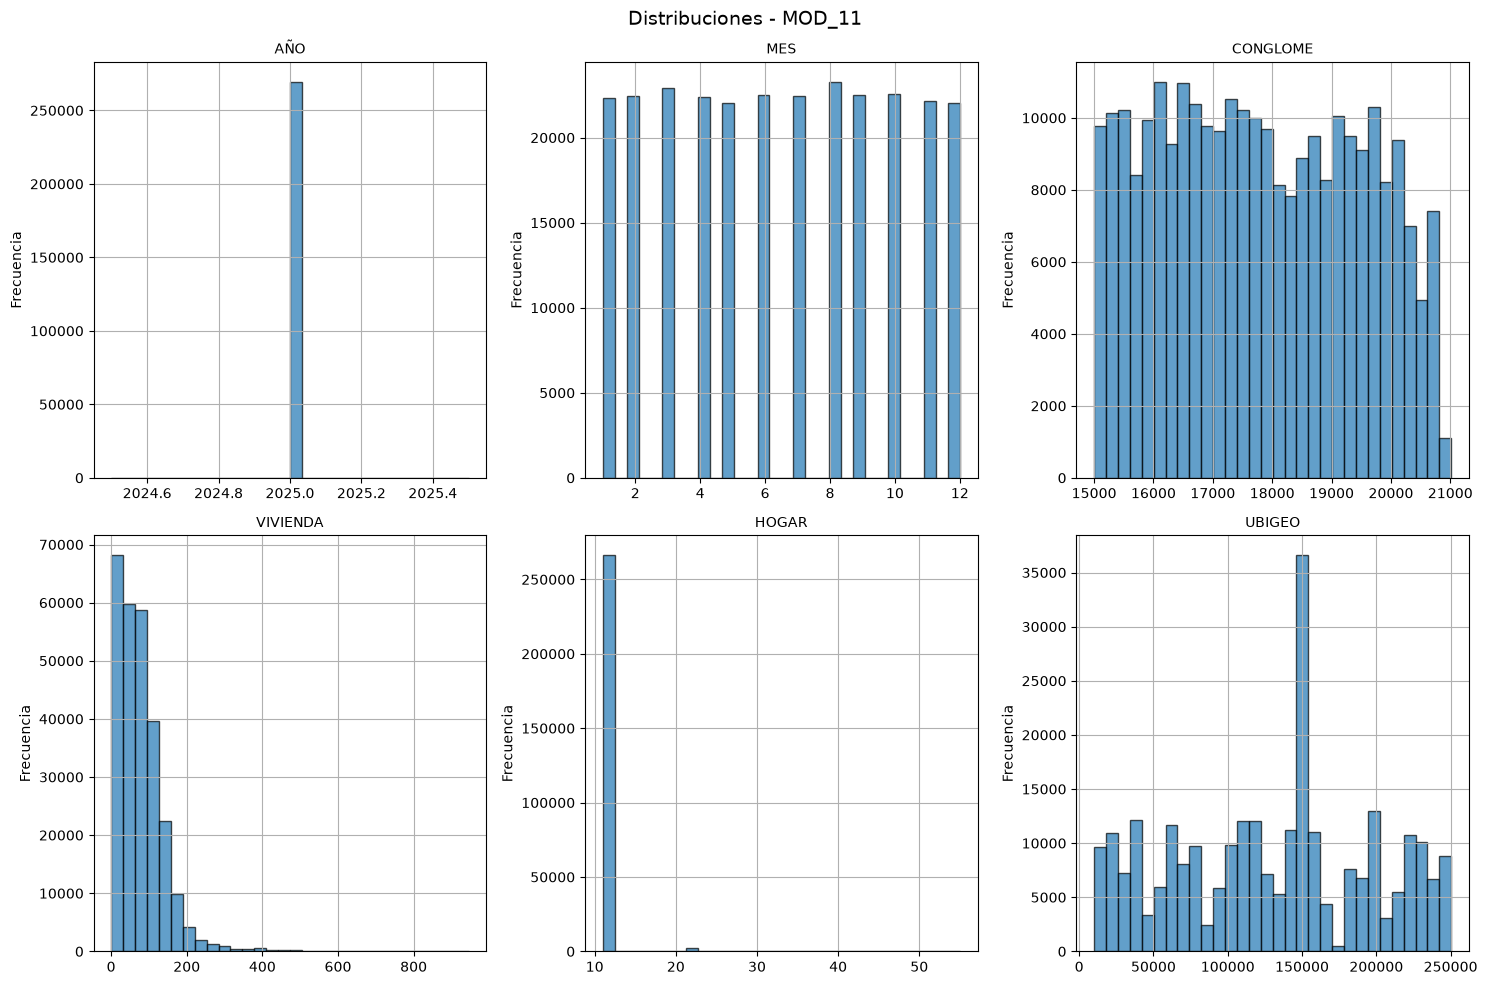


Modulo: MOD_16 - Generando histogramas


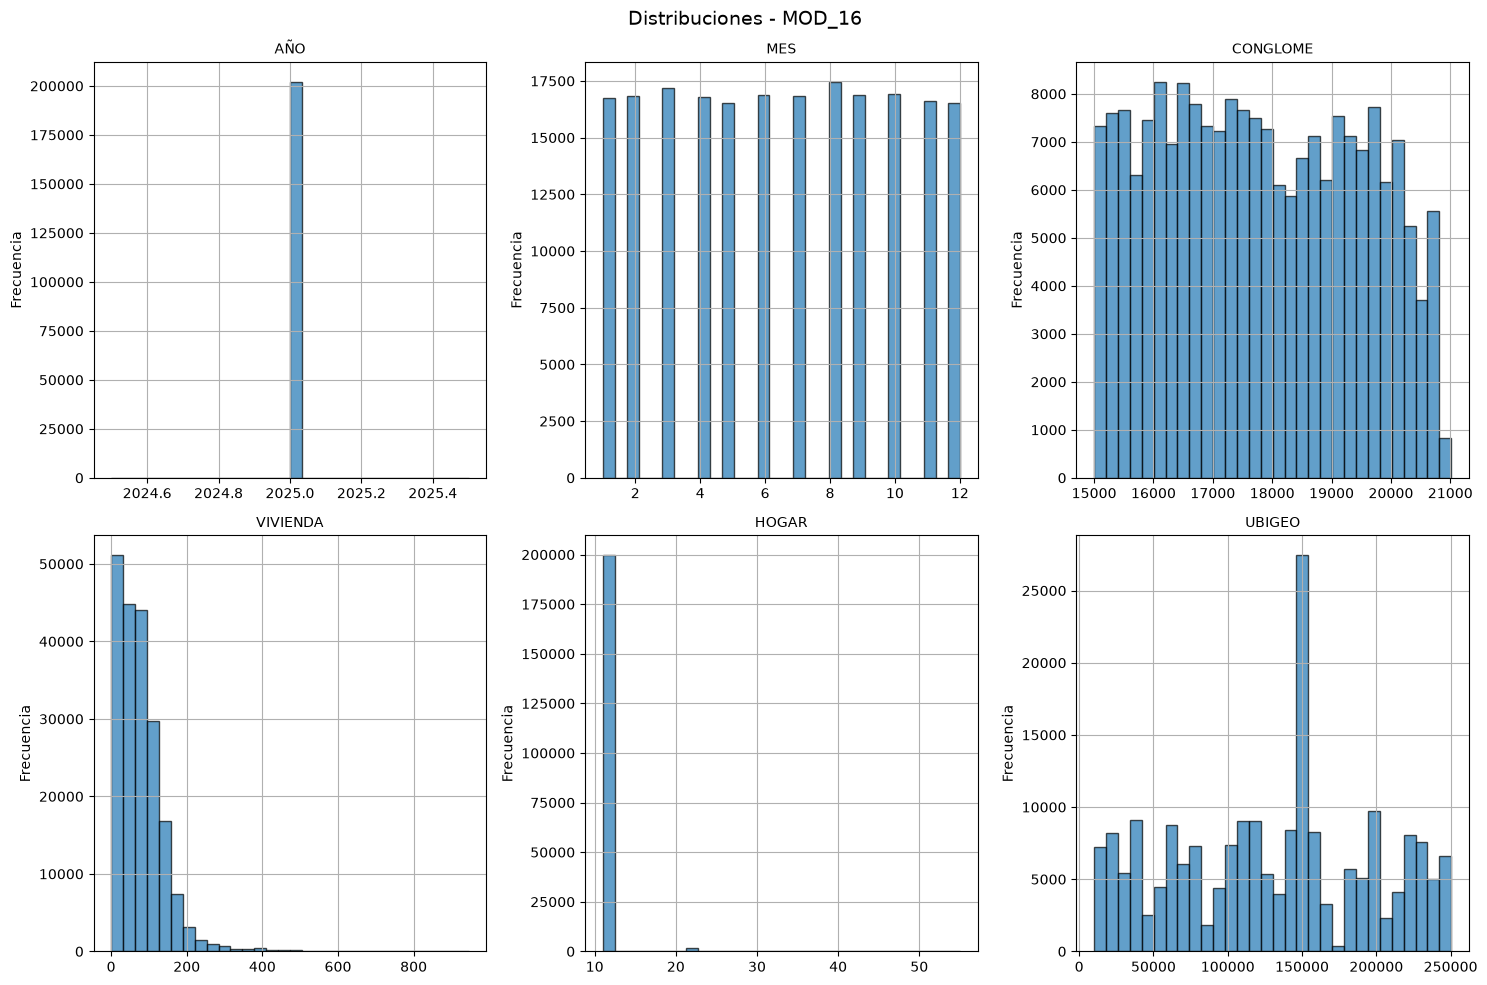


Modulo: MOD_34 - Generando histogramas


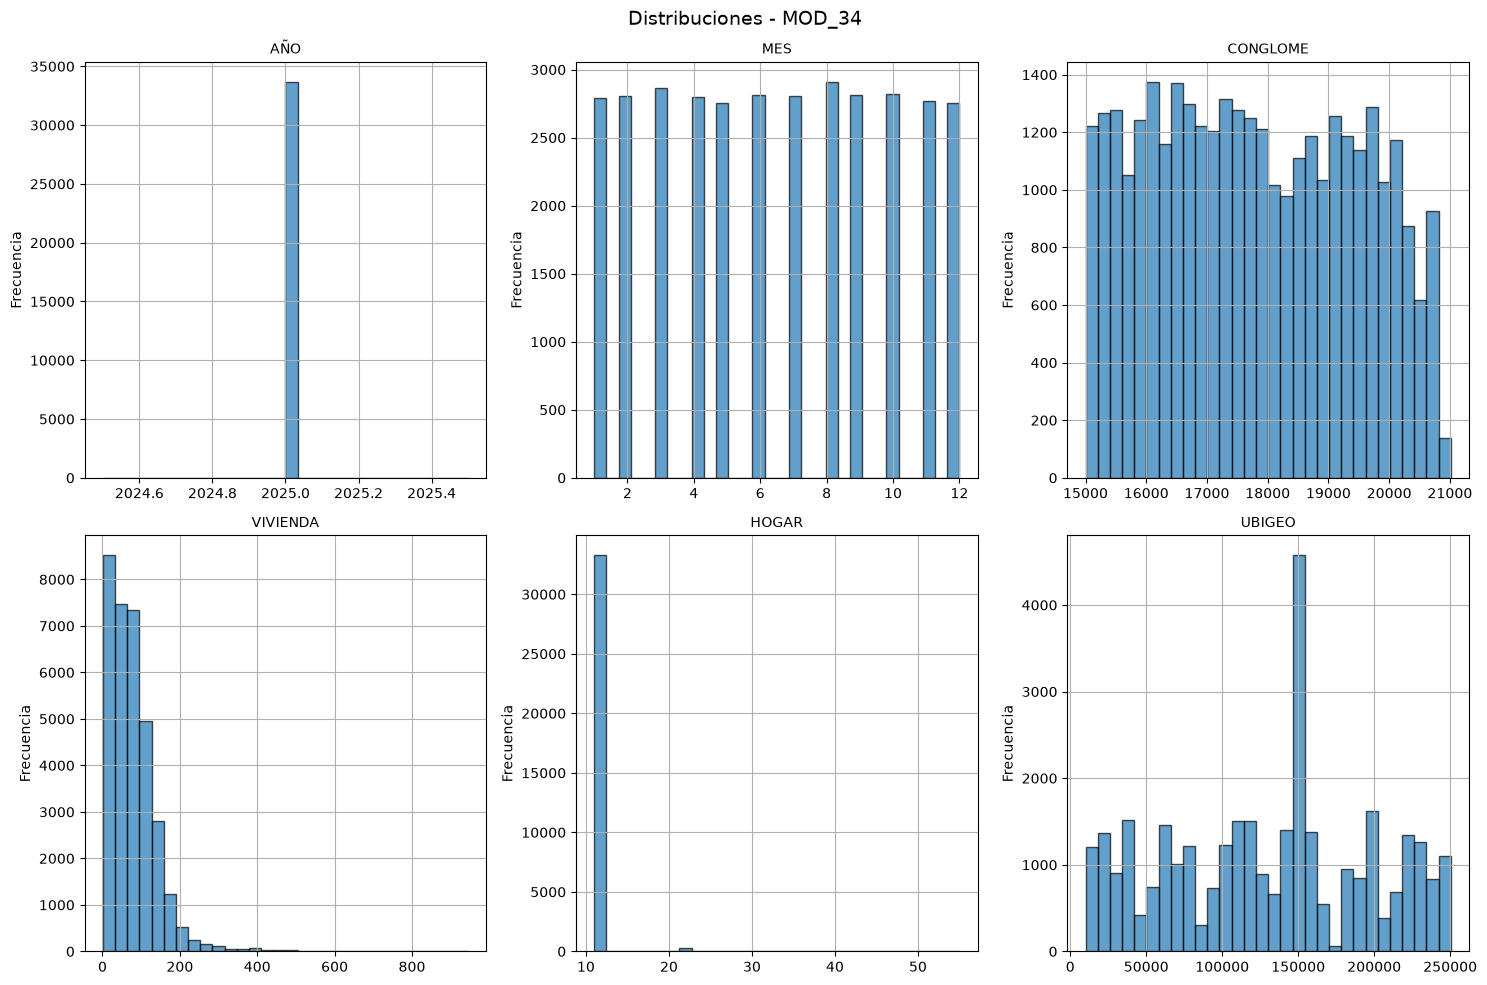


Modulo: MOD_37 - Generando histogramas


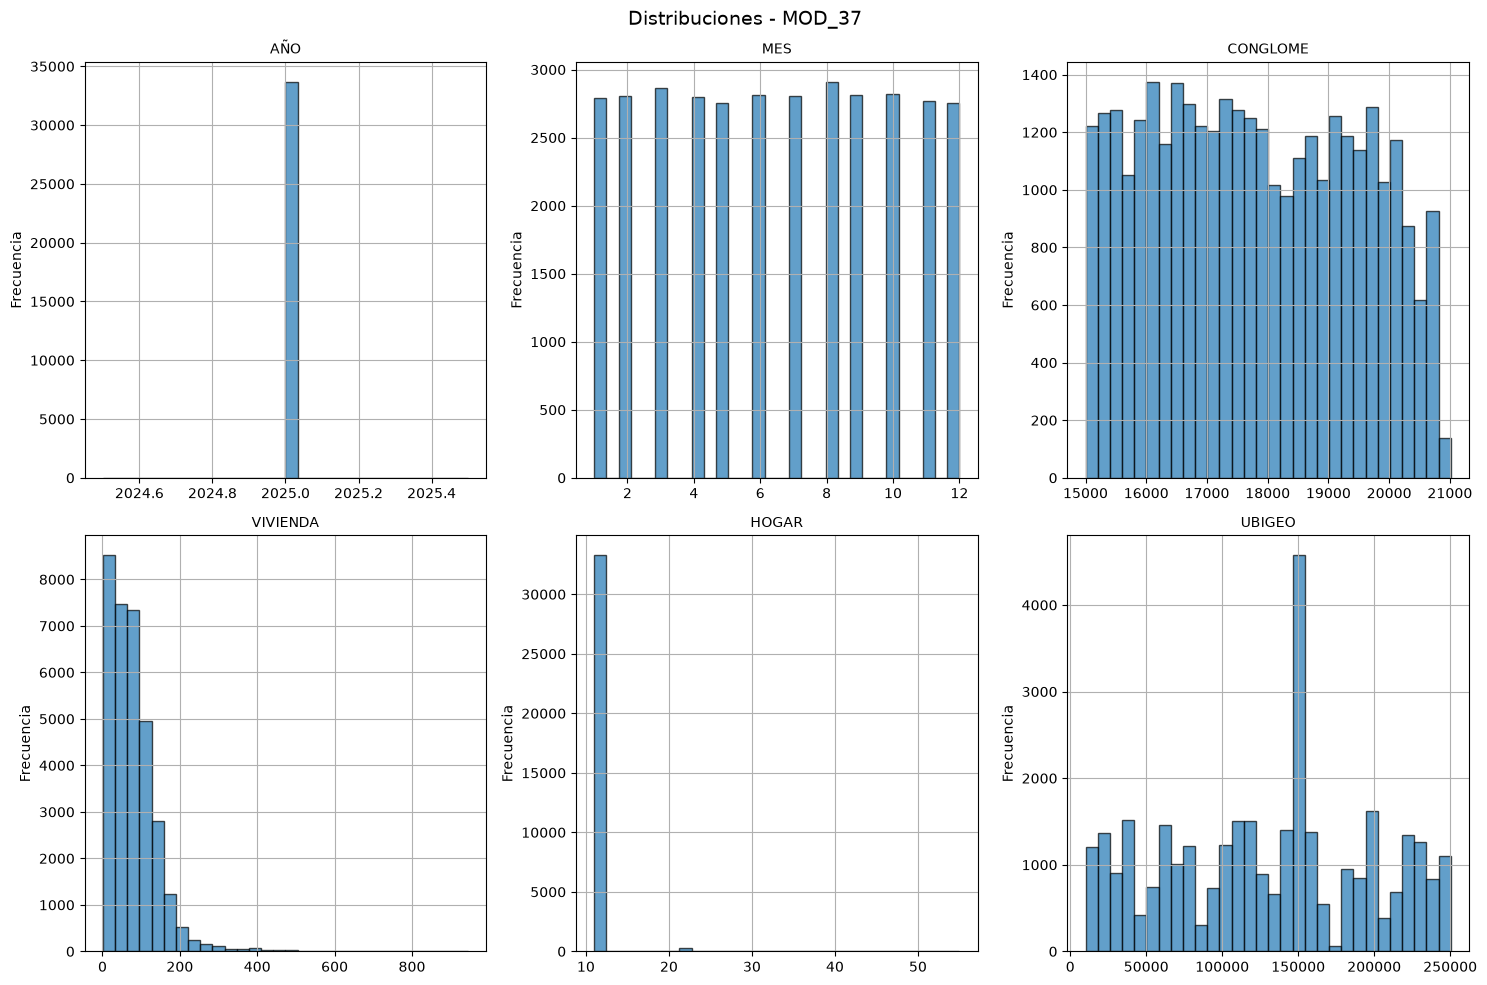

In [9]:
print("\n" + "="*70)
print("HISTOGRAMAS - DISTRIBUCIONES")
print("="*70)

for nombre, df in modulos.items():
    df_num = df.select_dtypes(include=['float64', 'int64'])
    
    if len(df_num.columns) >= 4:
        print(f"\nModulo: {nombre.upper()} - Generando histogramas")
        
        # Graficar primeras 6 variables numericas
        n_graficos = min(6, len(df_num.columns))
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        for i in range(n_graficos):
            col = df_num.columns[i]
            df_num[col].hist(ax=axes[i], bins=30, edgecolor='black', alpha=0.7)
            axes[i].set_title(f'{col[:35]}', fontsize=10)
            axes[i].set_xlabel('')
            axes[i].set_ylabel('Frecuencia')
        
        # Ocultar graficos vacios
        for i in range(n_graficos, 6):
            axes[i].set_visible(False)
        
        plt.suptitle(f'Distribuciones - {nombre.upper()}', fontsize=14)
        plt.tight_layout()
        plt.show()
    else:
        print(f"\nModulo: {nombre.upper()} - Pocas variables numericas ({len(df_num.columns)}), no se generan histogramas")

### PASO 7: BOXPLOTS (DETECCION DE OUTLIERS)

¿Hay valores extremos? ¿Están muy lejos?


BOXPLOTS - DETECCION DE OUTLIERS

Modulo: MOD_01 - Generando boxplots...


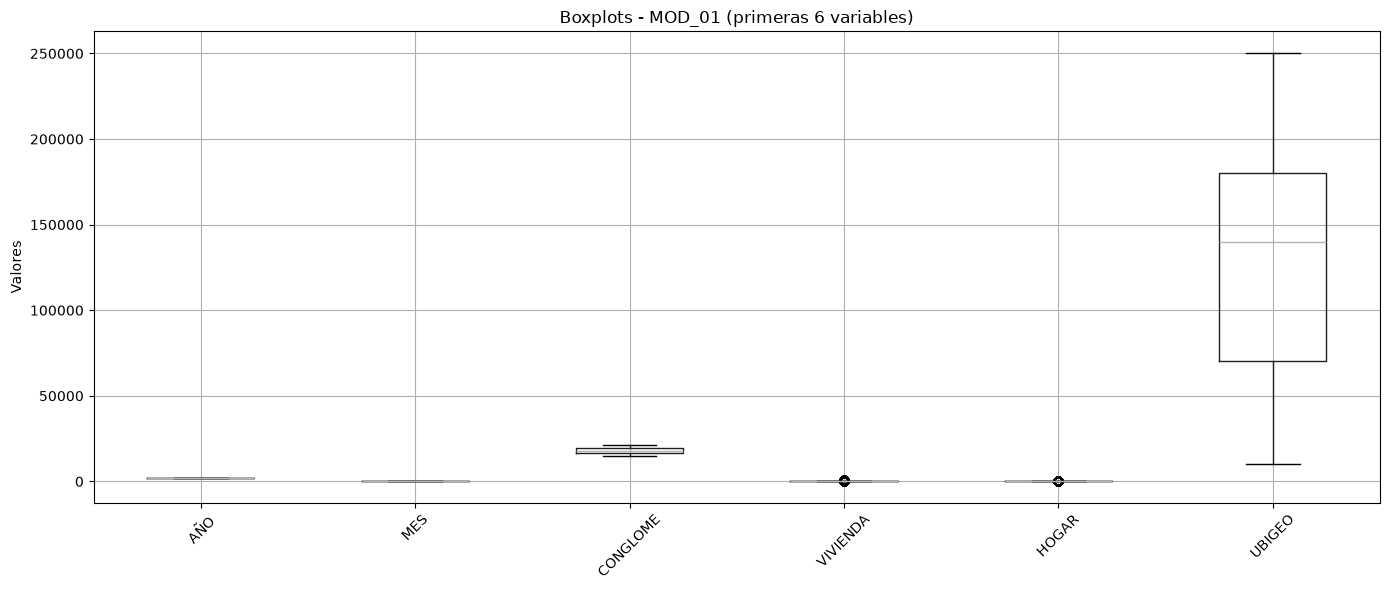


Modulo: MOD_01 - Conteo de outliers:
   AÑO: 0 outliers (0.0%)
   MES: 0 outliers (0.0%)
   CONGLOME: 0 outliers (0.0%)
   VIVIENDA: 1,187 outliers (2.7%)

Modulo: MOD_02 - Generando boxplots...


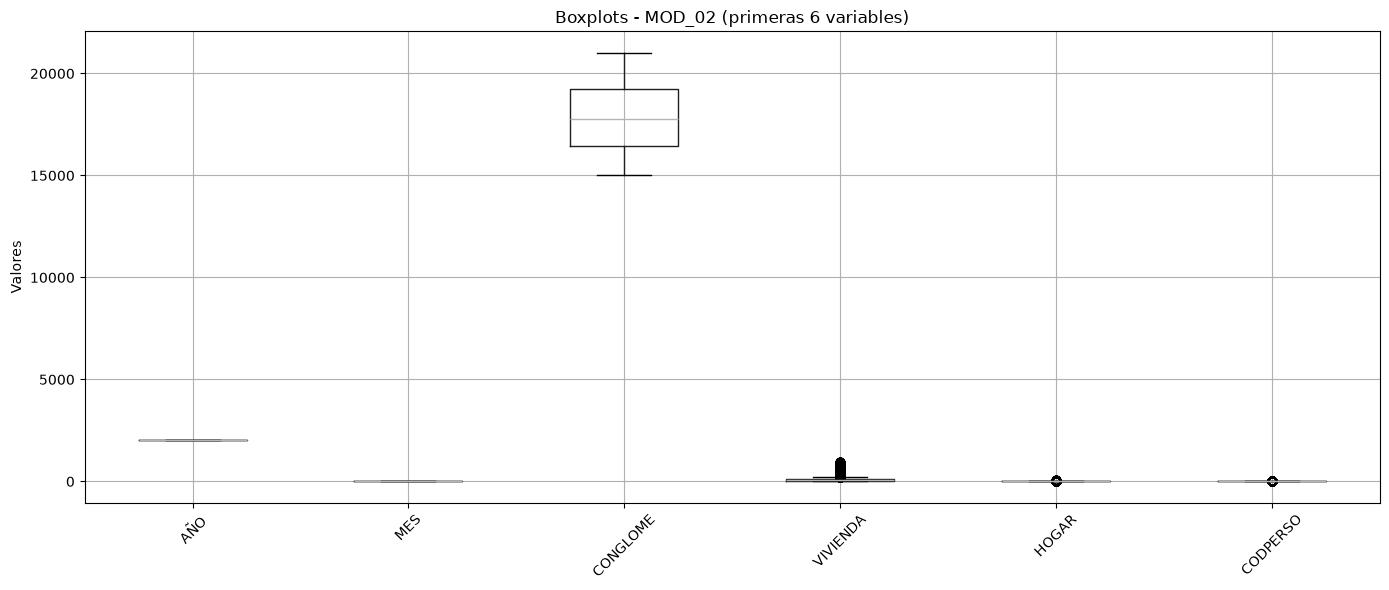


Modulo: MOD_02 - Conteo de outliers:
   AÑO: 0 outliers (0.0%)
   MES: 0 outliers (0.0%)
   CONGLOME: 0 outliers (0.0%)
   VIVIENDA: 3,173 outliers (2.8%)

Modulo: MOD_03 - Generando boxplots...


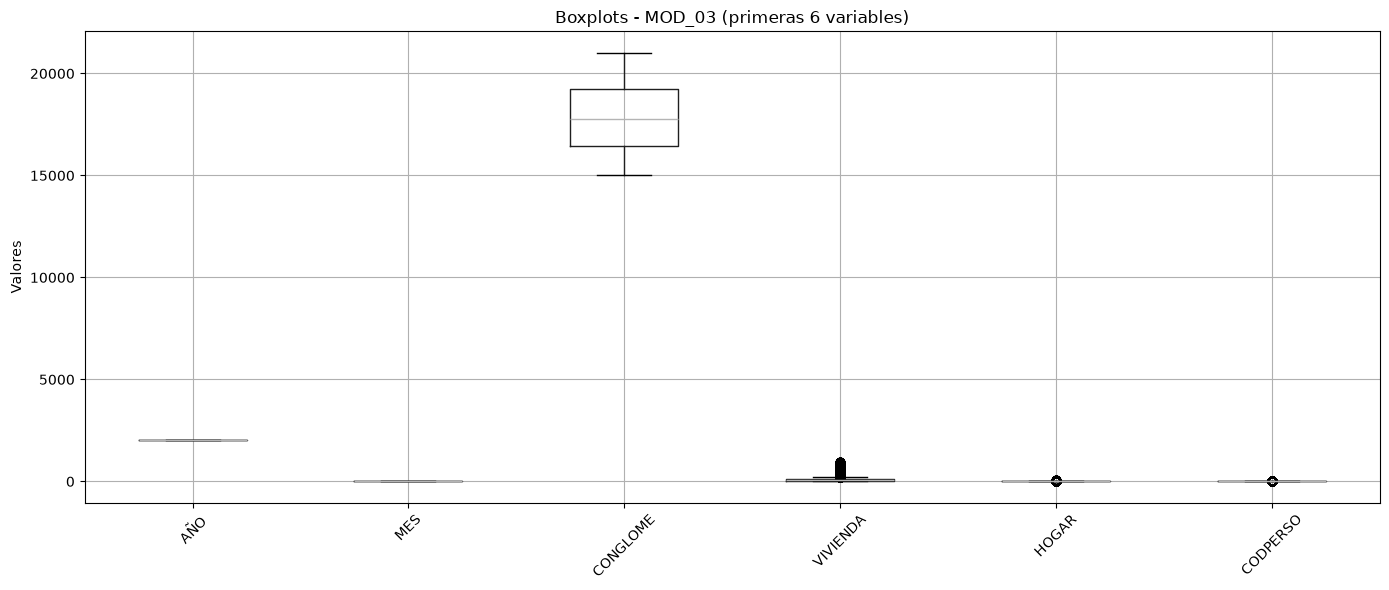


Modulo: MOD_03 - Conteo de outliers:
   AÑO: 0 outliers (0.0%)
   MES: 0 outliers (0.0%)
   CONGLOME: 0 outliers (0.0%)
   VIVIENDA: 2,783 outliers (2.7%)

Modulo: MOD_05 - Generando boxplots...


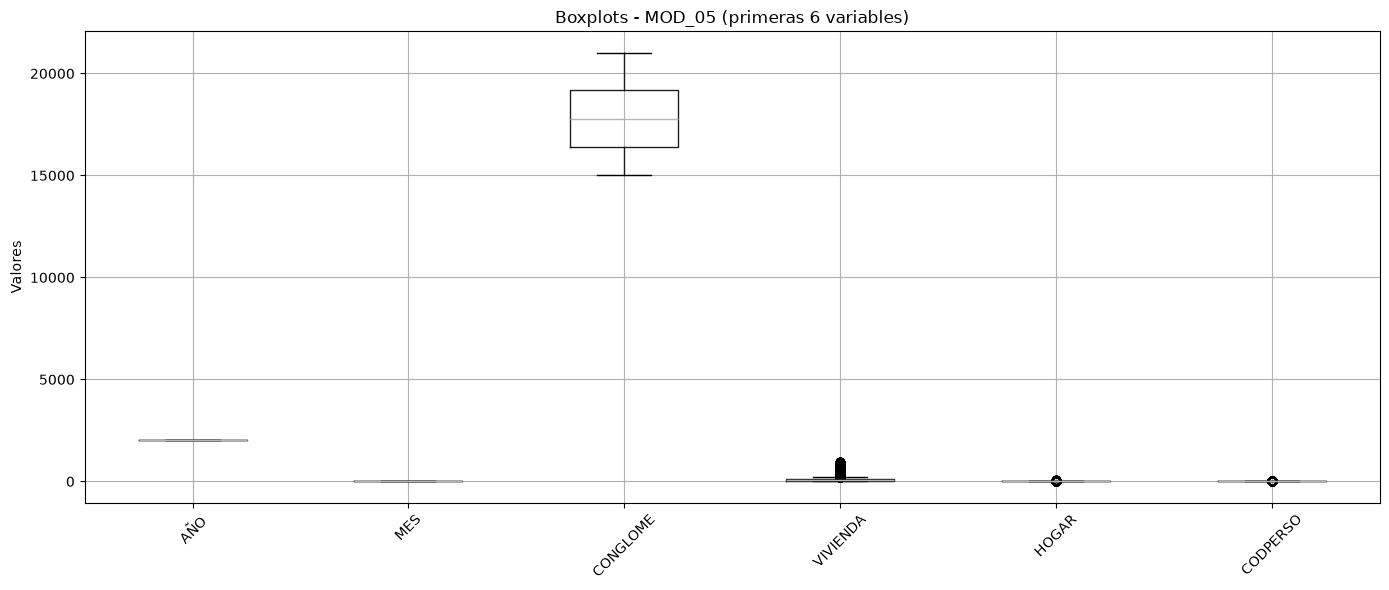


Modulo: MOD_05 - Conteo de outliers:
   AÑO: 0 outliers (0.0%)
   MES: 0 outliers (0.0%)
   CONGLOME: 0 outliers (0.0%)
   VIVIENDA: 2,248 outliers (2.6%)

Modulo: MOD_11 - Generando boxplots...


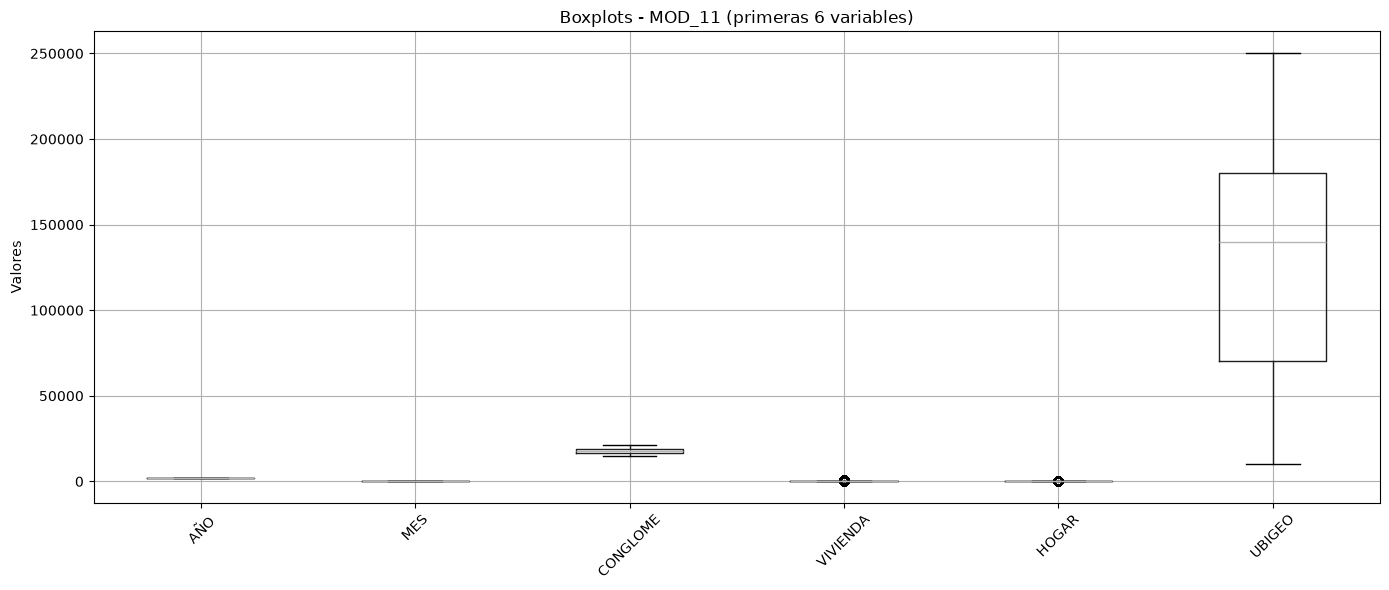


Modulo: MOD_11 - Conteo de outliers:
   AÑO: 0 outliers (0.0%)
   MES: 0 outliers (0.0%)
   CONGLOME: 0 outliers (0.0%)
   VIVIENDA: 7,208 outliers (2.7%)

Modulo: MOD_16 - Generando boxplots...


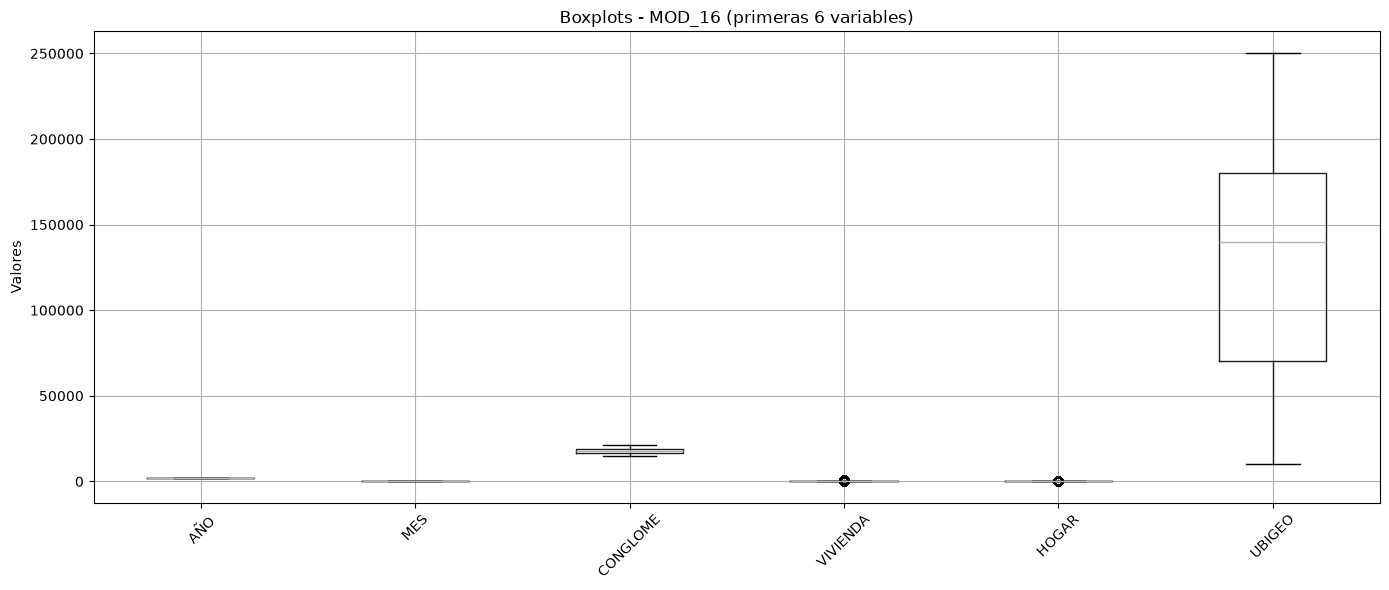


Modulo: MOD_16 - Conteo de outliers:
   AÑO: 0 outliers (0.0%)
   MES: 0 outliers (0.0%)
   CONGLOME: 0 outliers (0.0%)
   VIVIENDA: 5,406 outliers (2.7%)

Modulo: MOD_34 - Generando boxplots...


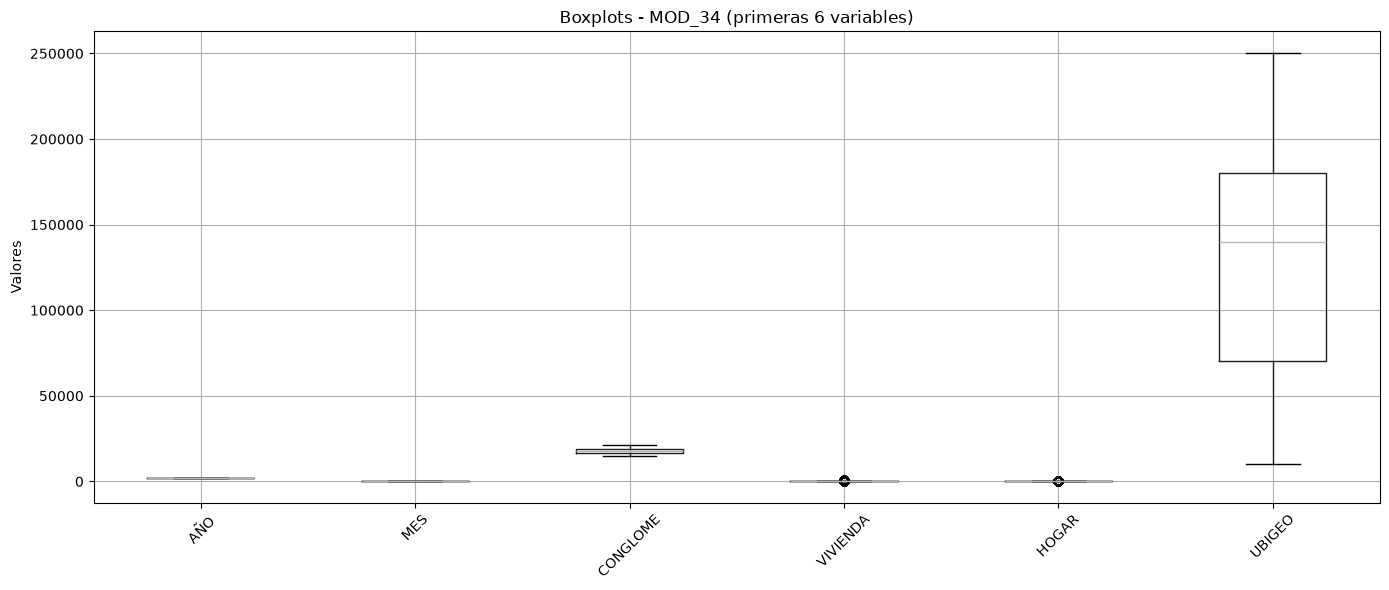


Modulo: MOD_34 - Conteo de outliers:
   AÑO: 0 outliers (0.0%)
   MES: 0 outliers (0.0%)
   CONGLOME: 0 outliers (0.0%)
   VIVIENDA: 901 outliers (2.7%)

Modulo: MOD_37 - Generando boxplots...


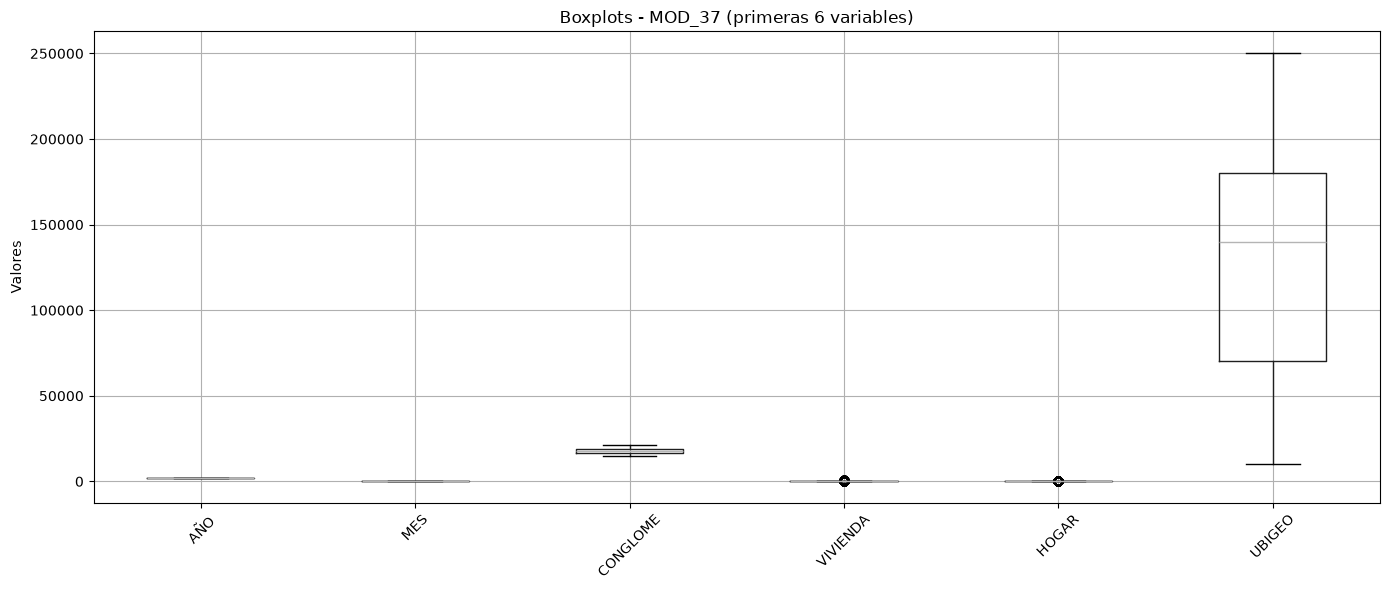


Modulo: MOD_37 - Conteo de outliers:
   AÑO: 0 outliers (0.0%)
   MES: 0 outliers (0.0%)
   CONGLOME: 0 outliers (0.0%)
   VIVIENDA: 901 outliers (2.7%)


In [ ]:
print("\n" + "="*70)
print("BOXPLOTS - DETECCION DE OUTLIERS")
print("="*70)

for nombre, df in modulos.items():
    df_num = df.select_dtypes(include=['float64', 'int64'])
    
    if len(df_num.columns) >= 4:
        print(f"\nModulo: {nombre.upper()} - Generando boxplots...")
        
        fig, ax = plt.subplots(figsize=(14, 6))
        df_num.iloc[:, :6].boxplot(ax=ax, rot=45)
        ax.set_title(f'Boxplots - {nombre.upper()} (primeras 6 variables)', fontsize=12)
        ax.set_ylabel('Valores')
        plt.tight_layout()
        plt.show()
        
        # Funcion para contar outliers
        def contar_outliers(serie):
            Q1 = serie.quantile(0.25)
            Q3 = serie.quantile(0.75)
            IQR = Q3 - Q1
            limite_inf = Q1 - 1.5 * IQR
            limite_sup = Q3 + 1.5 * IQR
            return ((serie < limite_inf) | (serie > limite_sup)).sum()
        
        print(f"\nModulo: {nombre.upper()} - Conteo de outliers:")
        for col in df_num.columns[:4]:
            n_outliers = contar_outliers(df_num[col])
            pct_outliers = (n_outliers / len(df_num)) * 100
            print(f"   {col}: {n_outliers:,} outliers ({pct_outliers:.1f}%)")
    else:
        print(f"\nModulo: {nombre.upper()} - Pocas variables numericas, no se generan boxplots")

### PASO 8: MATRIZ DE CORRELACION (RELACION ENTRE VARIABLES)

¿Dos variables se mueven juntas?


MATRIZ DE CORRELACION

Modulo: MOD_01 - Correlaciones:

   Top 5 correlaciones mas altas:
      MES ↔ FECENT: 0.978
      CONGLOME ↔ UBIGEO: 0.891
      P1175$11 ↔ P1175$13: 0.869
      ESTRATO ↔ TIPENC: 0.721
      ESTRATO ↔ CODCCPP: 0.468

Modulo: MOD_02 - Correlaciones:

   Top 5 correlaciones mas altas:
      CONGLOME ↔ UBIGEO: 0.895
      CODPERSO ↔ P203: 0.479
      DOMINIO ↔ NCONGLOME: 0.157
      VIVIENDA ↔ ESTRATO: 0.129
      P201P ↔ P203: 0.125


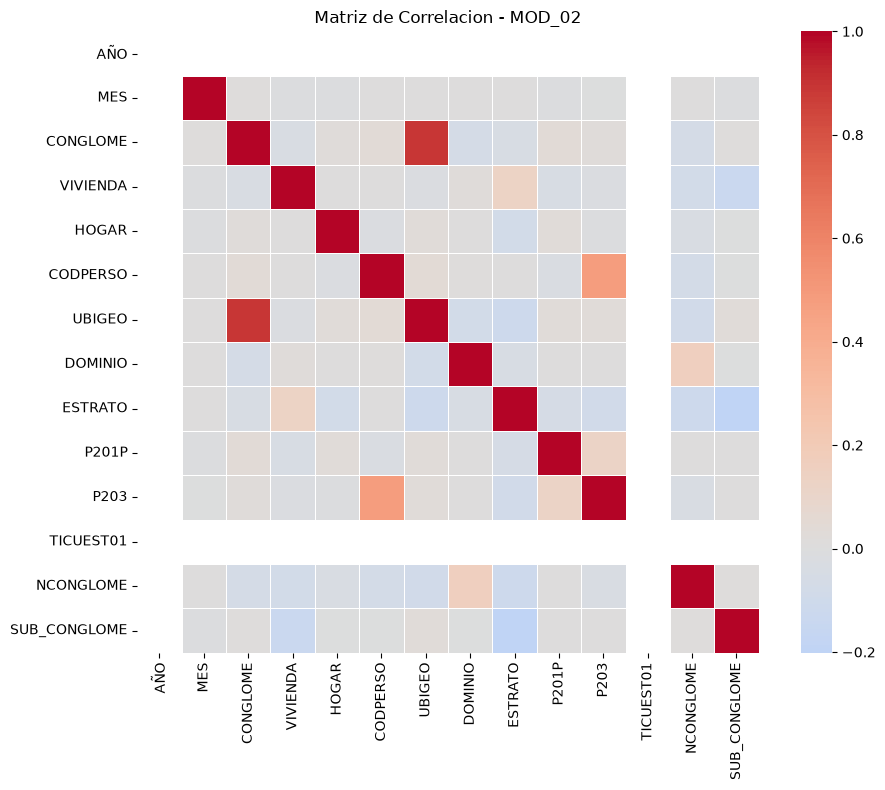


Modulo: MOD_03 - Correlaciones:

   Top 5 correlaciones mas altas:
      CODPERSO ↔ P300N: 1.000
      CODINFOR ↔ P300I: 1.000
      CONGLOME ↔ UBIGEO: 0.893
      P300A ↔ P301A: 0.730
      CODPERSO ↔ CODINFOR: 0.643

Modulo: MOD_05 - Correlaciones:

   Top 5 correlaciones mas altas:
      CODPERSO ↔ P500N: 1.000
      CODINFOR ↔ P500I: 1.000
      P55621B ↔ P55621C: 1.000
      P55627D ↔ P55627E: 1.000
      P55623B ↔ P55623C: 0.999

Modulo: MOD_11 - Correlaciones:

   Top 5 correlaciones mas altas:
      CONGLOME ↔ UBIGEO: 0.888
      DOMINIO ↔ NCONGLOME: 0.159
      DOMINIO ↔ P605: 0.119
      VIVIENDA ↔ ESTRATO: 0.113
      UBIGEO ↔ P605: 0.032


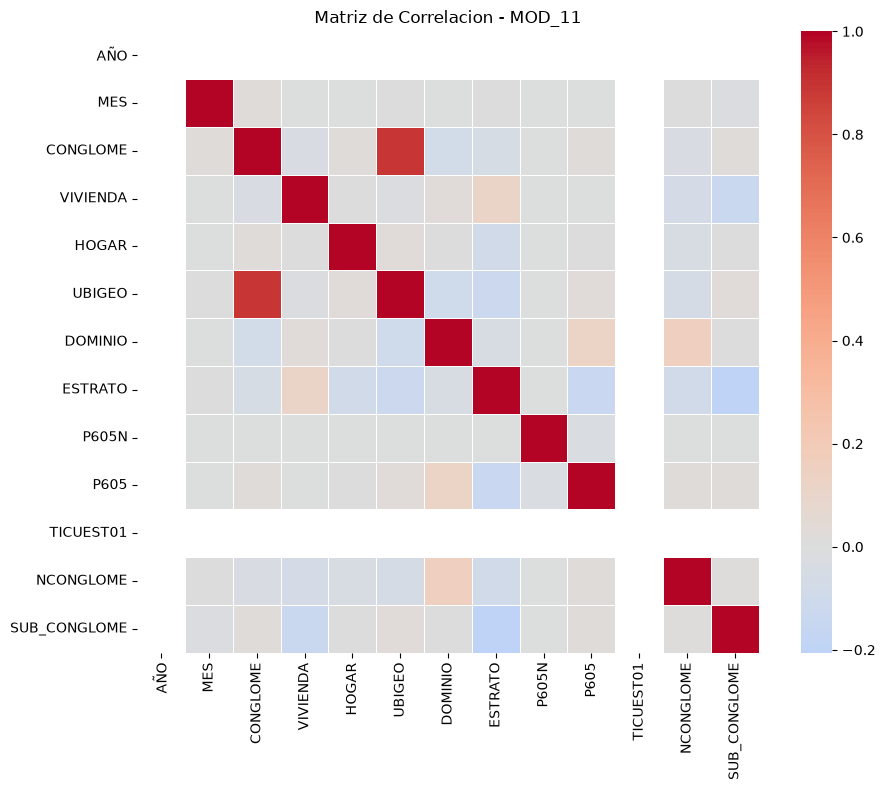


Modulo: MOD_16 - Correlaciones:

   Top 5 correlaciones mas altas:
      CONGLOME ↔ UBIGEO: 0.888
      DOMINIO ↔ NCONGLOME: 0.159
      DOMINIO ↔ P610: 0.140
      VIVIENDA ↔ ESTRATO: 0.113
      UBIGEO ↔ SUB_CONGLOME: 0.032


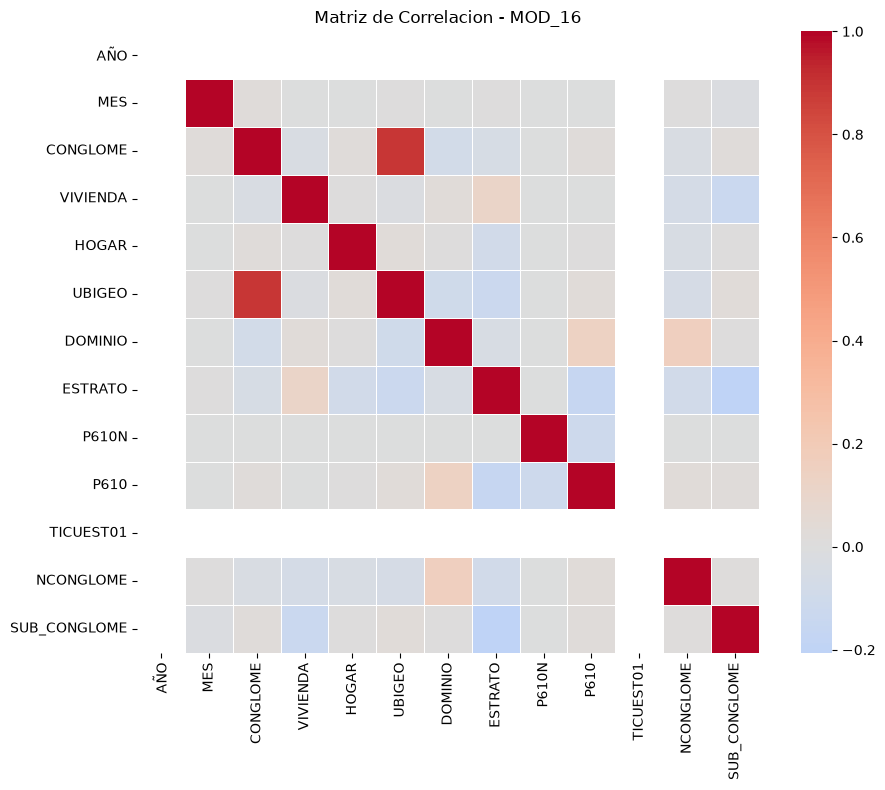


Modulo: MOD_34 - Correlaciones:

   Top 5 correlaciones mas altas:
      MIEPERHO ↔ TOTMIEHO: 0.996
      INGTPUHD ↔ INGTPU02: 0.975
      CONGLOME ↔ UBIGEO: 0.888
      POBREZA ↔ POBREZAV: 0.843
      INGTRAHD ↔ INGTPUHD: 0.829

Modulo: MOD_37 - Correlaciones:

   Top 5 correlaciones mas altas:
      P700I ↔ P710I: 0.946
      CONGLOME ↔ UBIGEO: 0.888
      DOMINIO ↔ NCONGLOME: 0.159
      ESTRATO ↔ P710I: 0.128
      ESTRATO ↔ P700I: 0.126


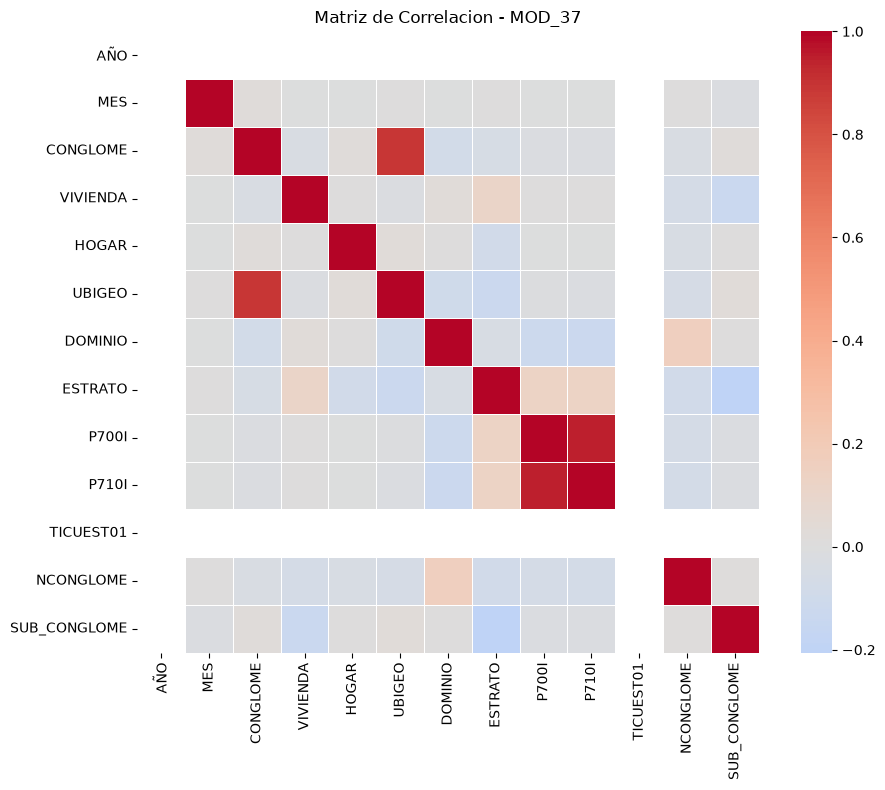

In [ ]:
print("\n" + "="*70)
print("MATRIZ DE CORRELACION")
print("="*70)


for nombre, df in modulos.items():
    df_num = df.select_dtypes(include=['float64', 'int64'])
    
    if len(df_num.columns) >= 4:
        print(f"\nModulo > {nombre.upper()} - Correlaciones:")
        
        # Matriz de correlacion
        corr = df_num.corr()
        
        # Mostrar correlaciones mas altas
        corr_stack = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        corr_stack = corr_stack.stack().sort_values(ascending=False)
        
        if len(corr_stack) > 0:
            print("\n   Top 5 correlaciones mas altas:")
            for idx, val in corr_stack.head(5).items():
                print(f"      {idx[0]} <-> {idx[1]}: {val:.3f}")
        
        # Heatmap
        if len(df_num.columns) <= 15:
            plt.figure(figsize=(10, 8))
            sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, 
                       square=True, linewidths=0.5)
            plt.title(f'Matriz de Correlacion - {nombre.upper()}')
            plt.tight_layout()
            plt.show()
    else:
        print(f"\nModulo: {nombre.upper()} - Pocas variables numericas, no se calcula correlacion")

### PASO 9: ANALISIS DE VARIABLES CATEGORICAS

¿Qué categorías existen?

In [10]:
print("\n" + "="*70)
print("PASO 2.8: ANALISIS DE VARIABLES CATEGORICAS")
print("="*70)

for nombre, df in modulos.items():
    cat_cols = df.select_dtypes(include=['object']).columns
    
    if len(cat_cols) > 0:
        print(f"\nModulo: {nombre.upper()} - Variables categoricas ({len(cat_cols)} columnas):")
        
        for col in list(cat_cols)[:5]:  # Mostrar primeras 5
            n_unique = df[col].nunique()
            print(f"\n{col}:")
            print(f"      Valores unicos: {n_unique}")
            
            if n_unique <= 10:
                print(f"      Distribucion:")
                for valor, count in df[col].value_counts().head(5).items():
                    pct = (count / len(df)) * 100
                    print(f"         {valor}: {count:,} ({pct:.1f}%)")
            else:
                print(f"      (Demasiados valores unicos para mostrar)")
        
        if len(cat_cols) > 5:
            print(f"\n   ... y {len(cat_cols) - 5} columnas categoricas mas")
    else:
        print(f"\nModulo: {nombre.upper()} - No tiene variables categoricas")


PASO 2.8: ANALISIS DE VARIABLES CATEGORICAS

Modulo: MOD_01 - Variables categoricas (304 columnas):

PANEL:
      Valores unicos: 3
      Distribucion:
          : 34,600 (77.6%)
         1: 9,962 (22.3%)
         2: 37 (0.1%)

P22:
      Valores unicos: 3
      Distribucion:
         2: 30,396 (68.2%)
          : 10,897 (24.4%)
         1: 3,306 (7.4%)

P23:
      Valores unicos: 860
      (Demasiados valores unicos para mostrar)

P24A:
      Valores unicos: 5
      Distribucion:
         1: 15,386 (34.5%)
          : 10,897 (24.4%)
         3: 10,784 (24.2%)
         4: 5,209 (11.7%)
         2: 2,323 (5.2%)

P24B:
      Valores unicos: 4
      Distribucion:
         3: 15,471 (34.7%)
         1: 14,759 (33.1%)
          : 10,887 (24.4%)
         2: 3,482 (7.8%)

   ... y 299 columnas categoricas mas

Modulo: MOD_02 - Variables categoricas (26 columnas):

P203A:
      Valores unicos: 8
      Distribucion:
         1: 86,995 (75.6%)
         0: 14,990 (13.0%)
         2: 7,884 (6.8%)

## LIMPIEZA DE DATOS

### CHECK 1: VALORES NULOS Y ESPECIALES

##### BLOQUE 1: REEMPLAZAR VALORES ESPECIALES POR NaN

In [ ]:
# Definir valores especiales de ENAHO (estándar)
valores_especiales = [-1, 99, 999, 9999, 99999, 999999]

def limpiar_valores_especiales(df, nombre=""):
    """Reemplaza valores especiales por NaN y muestra el cambio"""
    antes = df.isna().sum().sum()
    df_limpio = df.replace(valores_especiales, np.nan)
    despues = df_limpio.isna().sum().sum()
    diferencia = despues - antes
    print(f"  {nombre}: {antes:,} → {despues:,} nulos (+{diferencia:,} nuevos)")
    return df_limpio

print("\nReemplazando valores especiales en todos los módulos:")

for nombre in modulos.keys():
    modulos[nombre] = limpiar_valores_especiales(modulos[nombre], nombre)

print("\nTodos los valores especiales han sido reemplazados por NaN")


CHECK 1. REEMPLAZAR VALORES ESPECIALES POR NaN

Reemplazando valores especiales en todos los módulos:
  mod_01: 300 → 300 nulos (+0 nuevos)
  mod_02: 678 → 678 nulos (+0 nuevos)
  mod_03: 841 → 841 nulos (+0 nuevos)
  mod_05: 592 → 592 nulos (+0 nuevos)
  mod_11: 1,616 → 1,616 nulos (+0 nuevos)
  mod_16: 1,212 → 1,212 nulos (+0 nuevos)
  mod_34: 229 → 229 nulos (+0 nuevos)
  mod_37: 202 → 202 nulos (+0 nuevos)

Todos los valores especiales han sido reemplazados por NaN


##### BLOQUE 2: VERIFICAR REMPLAZO

In [ ]:
print("\nBuscando valores especiales que hayan quedado:")
print("-" * 50)

# Buscar cada valor especial en todos los módulos
for val in valores_especiales:
    total = 0
    for nombre, df in modulos.items():
        total += (df == val).sum().sum()
    if total > 0:
        print(f"Aún hay {total:,} ocurrencias del valor {val}")
    else:
        print(f"No hay ocurrencias del valor {val}")

# Mostrar estadísticas de nulos actuales
print("\nNUEVOS NULOS POR MÓDULO (después del reemplazo):")
print("-" * 50)
for nombre, df in modulos.items():
    nulos = df.isna().sum().sum()
    total_celdas = df.shape[0] * df.shape[1]
    pct = (nulos / total_celdas) * 100
    print(f"  {nombre}: {nulos:,} nulos de {total_celdas:,} celdas ({pct:.2f}%)")

print("\nVerificación completada")


Buscando valores especiales que hayan quedado:
--------------------------------------------------
